In [ ]:
import pandas as pd

df = pd.read_csv('/content/credit_card_fraud_2025 (1).csv')
print(df.head())

   Transaction_ID  Customer_ID     Transaction_Date  Amount Merchant_Category  \
0               1        25795  2025-05-28 11:54:36   81.53   Online Services   
1               2        10860  2024-09-11 20:26:12   52.19              Fuel   
2               3        86820  2024-11-02 12:39:23   27.70         Utilities   
3               4        64886  2024-10-08 21:58:08    9.80          Clothing   
4               5        16265  2024-05-25 20:01:21  178.06       Electronics   

   Merchant_ID Card_Type Transaction_Type  Country  Is_International  Is_Chip  \
0         8459      Gold              POS  Germany                 1        1   
1         8205     Debit              ATM  Germany                 0        1   
2         8076      Gold           Online      USA                 0        1   
3         3244      Gold              ATM      USA                 0        1   
4         3675      Gold              ATM  Germany                 0        1   

   Is_Pin_Used  Distance_F

In [ ]:
#Filtering data
non_fraud = df[df['Fraud_Flag'] == 0]
fraud = df[df['Fraud_Flag'] == 1]

In [ ]:
non_fraud.head()

,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag
0,1,25795,2025-05-28 11:54:36,81.53,Online Services,8459,Gold,POS,Germany,1,1,0,1.61,11,Web,0
1,2,10860,2024-09-11 20:26:12,52.19,Fuel,8205,Debit,ATM,Germany,0,1,0,15.77,20,Web,0
2,3,86820,2024-11-02 12:39:23,27.70,Utilities,8076,Gold,Online,USA,0,1,0,9.19,12,Terminal,0
3,4,64886,2024-10-08 21:58:08,9.80,Clothing,3244,Gold,ATM,USA,0,1,0,9.42,21,Web,0
4,5,16265,2024-05-25 20:01:21,178.06,Electronics,3675,Gold,ATM,Germany,0,1,1,1.32,20,Web,0


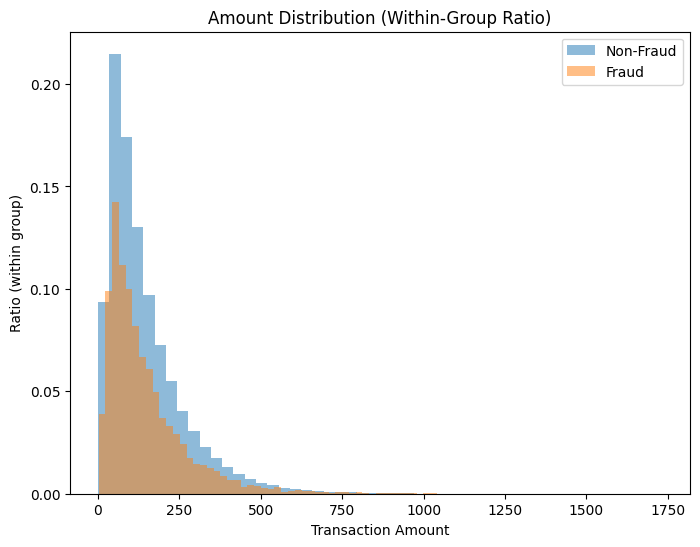

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))

# normalize each subset
nf_weights = np.ones(len(non_fraud)) / len(non_fraud)
f_weights = np.ones(len(fraud)) / len(fraud)

plt.hist(non_fraud['Amount'], bins=50,
         weights=nf_weights, alpha=0.5, label='Non-Fraud')

plt.hist(fraud['Amount'], bins=50,
         weights=f_weights, alpha=0.5, label='Fraud')

plt.xlabel('Transaction Amount')
plt.ylabel('Ratio (within group)')
plt.title('Amount Distribution (Within-Group Ratio)')
plt.legend()

plt.show()

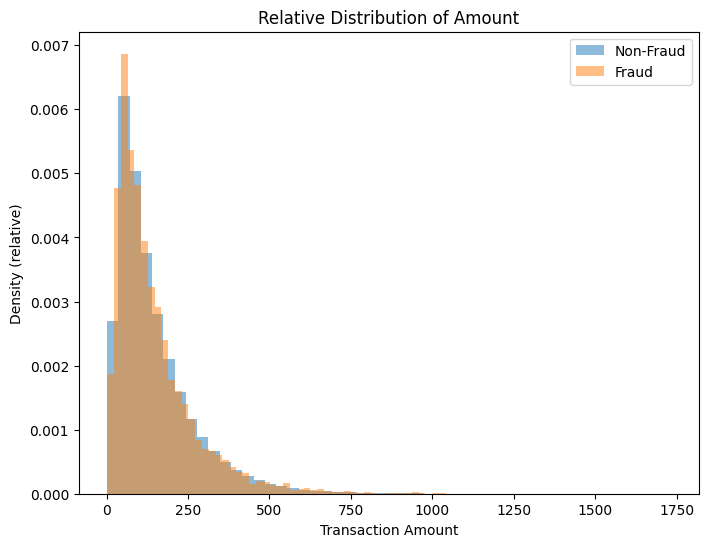

In [ ]:
#Too much non-fraud data
plt.figure(figsize=(8,6))

plt.hist(non_fraud['Amount'], bins=50, alpha=0.5, density=True, label='Non-Fraud')
plt.hist(fraud['Amount'], bins=50, alpha=0.5, density=True, label='Fraud')

plt.xlabel('Transaction Amount')
plt.ylabel('Density (relative)')
plt.title('Relative Distribution of Amount')
plt.legend()

plt.show()

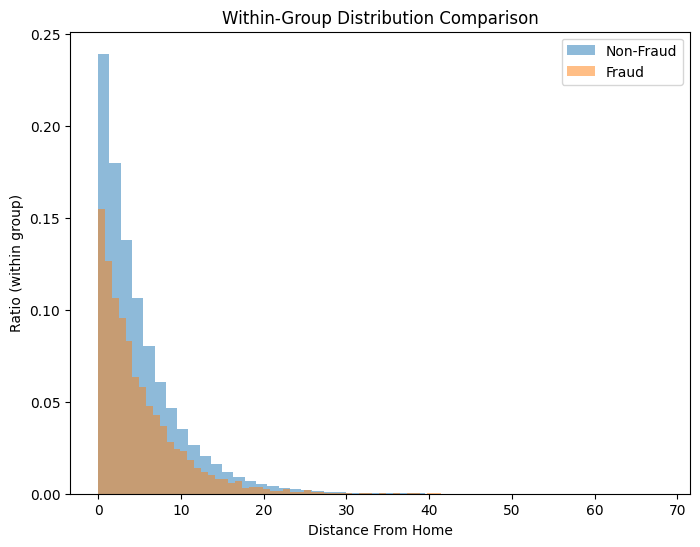

In [ ]:
plt.figure(figsize=(8,6))

# normalize within each group
nf_weights = np.ones(len(non_fraud)) / len(non_fraud)
f_weights = np.ones(len(fraud)) / len(fraud)

plt.hist(non_fraud['Distance_From_Home'], bins=50,
         weights=nf_weights, alpha=0.5, label='Non-Fraud')

plt.hist(fraud['Distance_From_Home'], bins=50,
         weights=f_weights, alpha=0.5, label='Fraud')

plt.xlabel('Distance From Home')
plt.ylabel('Ratio (within group)')
plt.title('Within-Group Distribution Comparison')
plt.legend()

plt.show()

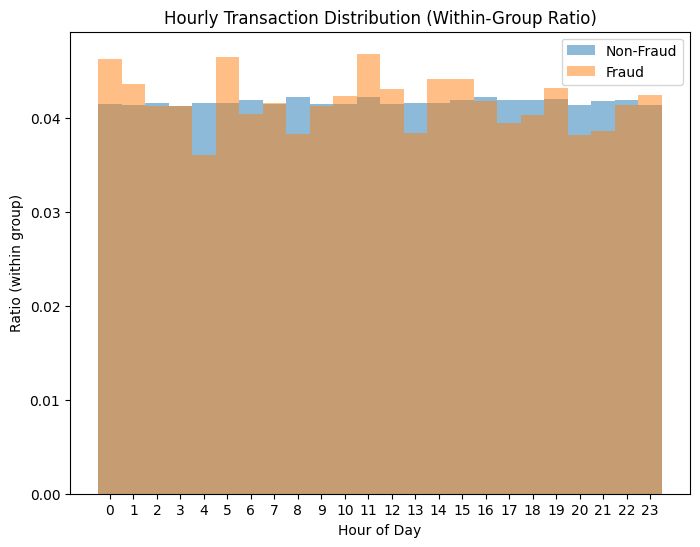

In [ ]:
#Useless
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))


nf_weights = np.ones(len(non_fraud)) / len(non_fraud)
f_weights = np.ones(len(fraud)) / len(fraud)


bins = np.arange(0, 25) - 0.5

plt.hist(non_fraud['Hour_of_Day'], bins=bins,
         weights=nf_weights, alpha=0.5, label='Non-Fraud')

plt.hist(fraud['Hour_of_Day'], bins=bins,
         weights=f_weights, alpha=0.5, label='Fraud')

plt.xlabel('Hour of Day')
plt.ylabel('Ratio (within group)')
plt.title('Hourly Transaction Distribution (Within-Group Ratio)')
plt.xticks(range(24))
plt.legend()

plt.show()

In [ ]:
fraud.describe()

,Transaction_ID,Customer_ID,Amount,Merchant_ID,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.0
mean,251309.099067,54878.261467,145.095821,5489.690533,0.147600,0.300933,0.200933,4.914968,11.410133,1.0
std,145202.959473,25907.079117,123.940499,2619.700991,0.354727,0.458694,0.400725,4.816775,6.926975,0.0
min,13.000000,10013.000000,2.210000,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,124242.250000,32712.250000,59.965000,3215.750000,0.000000,0.000000,0.000000,1.420000,5.000000,1.0
50%,251159.000000,54837.000000,107.390000,5481.500000,0.000000,0.000000,0.000000,3.470000,11.000000,1.0
75%,376081.750000,77375.500000,188.237500,7752.250000,0.000000,1.000000,0.000000,6.900000,17.000000,1.0
max,499970.000000,99995.000000,1040.870000,9997.000000,1.000000,1.000000,1.000000,41.410000,23.000000,1.0


In [ ]:
non_fraud.describe()

,Transaction_ID,Customer_ID,Amount,Merchant_ID,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag
count,492500.000000,492500.000000,492500.000000,492500.000000,492500.000000,492500.000000,492500.000000,492500.000000,492500.000000,492500.0
mean,249980.572095,55009.597232,145.270636,5501.401744,0.149155,0.300211,0.199783,5.003020,11.515269,0.0
std,144324.551738,25996.453983,120.835283,2597.146341,0.356242,0.458350,0.399837,5.001452,6.915091,0.0
min,1.000000,10000.000000,1.190000,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,125012.750000,32485.750000,60.810000,3255.000000,0.000000,0.000000,0.000000,1.430000,6.000000,0.0
50%,249978.500000,55060.000000,109.190000,5501.000000,0.000000,0.000000,0.000000,3.480000,12.000000,0.0
75%,374984.250000,77511.250000,192.290000,7751.000000,0.000000,1.000000,0.000000,6.920000,18.000000,0.0
max,500000.000000,99998.000000,1731.550000,9998.000000,1.000000,1.000000,1.000000,68.130000,23.000000,0.0


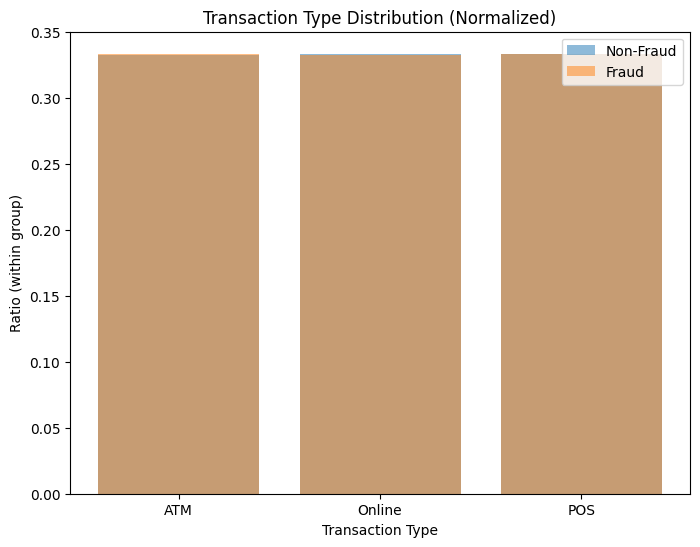

In [ ]:
fraud_dist = fraud['Transaction_Type'].value_counts(normalize=True)
nonfraud_dist = non_fraud['Transaction_Type'].value_counts(normalize=True)

all_categories = sorted(df['Transaction_Type'].unique())
fraud_dist = fraud_dist.reindex(all_categories, fill_value=0)
nonfraud_dist = nonfraud_dist.reindex(all_categories, fill_value=0)

plt.figure(figsize=(8,6))

x = range(len(all_categories))

plt.bar(x, nonfraud_dist.values, alpha=0.5, label='Non-Fraud')
plt.bar(x, fraud_dist.values, alpha=0.5, label='Fraud')

plt.xticks(x, all_categories)
plt.xlabel('Transaction Type')
plt.ylabel('Ratio (within group)')
plt.title('Transaction Type Distribution (Normalized)')
plt.legend()

plt.show()

In [ ]:
summary = df.groupby('Fraud_Flag')['Amount'].agg([
    'mean',
    'std',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
])


summary.columns = ['Mean', 'Std', '25th Percentile', '75th Percentile']

print(summary)

                  Mean         Std  25th Percentile  75th Percentile
Fraud_Flag                                                          
0           145.270636  120.835283           60.810         192.2900
1           145.095821  123.940499           59.965         188.2375


In [ ]:
from tabulate import tabulate

print(tabulate(summary, headers='keys', tablefmt='grid'))

+--------------+---------+---------+-------------------+-------------------+
|   Fraud_Flag |    Mean |     Std |   25th Percentile |   75th Percentile |
+==============+=========+=========+===================+===================+
|            0 | 145.271 | 120.835 |            60.81  |           192.29  |
+--------------+---------+---------+-------------------+-------------------+
|            1 | 145.096 | 123.94  |            59.965 |           188.237 |
+--------------+---------+---------+-------------------+-------------------+
